In [59]:
import pandas as pd

In [60]:
col_names = ['target', 'id', 'date', 'query', 'user', 'text']

In [61]:
df = pd.read_csv(r"training.1600000.processed.noemoticon.csv", encoding = 'latin-1', names=col_names)

In [62]:
df.head(5)

,target,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## 1. Data Cleaning

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   query   1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [64]:
df.shape

(1600000, 6)

In [65]:
# checking missing values
df.isnull().sum()

target    0
id        0
date      0
query     0
user      0
text      0
dtype: int64

In [66]:
# No missing values check duplicates
df.duplicated().sum()

np.int64(0)

In [67]:
df.shape

(1600000, 6)

In [68]:
# There are some unwanted columns in the df, we need to remove them
df = df.drop(columns=["id", "date", "query", "user"])

In [69]:
df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [70]:
df['target'].value_counts()

target
0    800000
4    800000
Name: count, dtype: int64

In [71]:
# Remvoing the special characters/symbols/letters/urls etc.
import re

In [72]:
def cleaning_text(text):
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text) # Strip URLs
    text = re.sub(r"@\S+", "", text) # Strip Mentions (@user)
    text = re.sub(r"[^a-z\s]", "", text) # Strip punctuation, numbers, and emojis
    text = re.sub(r"\s+", " ", text).strip() # Remove double/extra spaces
    return text

In [73]:
df['clean_text'] = df['text'].apply(cleaning_text)

In [74]:
df.head()

,target,text,clean_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,0,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,0,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


In [75]:
df.duplicated().sum()

np.int64(16309)

In [76]:
df.shape

(1600000, 3)

In [77]:
df = df.drop_duplicates(keep = 'first')

In [78]:
df.duplicated().sum()

np.int64(0)

In [79]:
df.shape

(1583691, 3)

In [80]:
df.head(10)

,target,text,clean_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,0,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,0,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,0,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...
5,0,@Kwesidei not the whole crew,not the whole crew
6,0,Need a hug,need a hug
7,0,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...
8,0,@Tatiana_K nope they didn't have it,nope they didnt have it
9,0,@twittera que me muera ?,que me muera


## 2. EDA

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [82]:
X = df['clean_text']
y = df['target']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 30)

In [89]:
tfidf_vectorizer = TfidfVectorizer(ngram_range = (1, 2))

In [90]:
X_tfidf_train = tfidf_vectorizer.fit_transform(X_train)
X_tfidf_test = tfidf_vectorizer.transform(X_test)

In [91]:
X_tfidf_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27527865 stored elements and shape (1266952, 3475290)>

In [92]:
from wordcloud import WordCloud

In [93]:
wc = WordCloud(width = 800, height = 400, max_words = 200, background_color = 'white', contour_width = 3, contour_color = 'steelblue')

In [94]:
df[df['target'] == 4]['clean_text'].head()

800000                             i love u guys r the best
800001    im meeting up with one of my besties tonight c...
800002    thanks for the twitter add sunisa i got to mee...
800003    being sick can be really cheap when it hurts t...
800004                       he has that effect on everyone
Name: clean_text, dtype: object

In [96]:
positive_wc = wc.generate(df[df['target'] == 4]['clean_text'].str.cat(sep=" "))

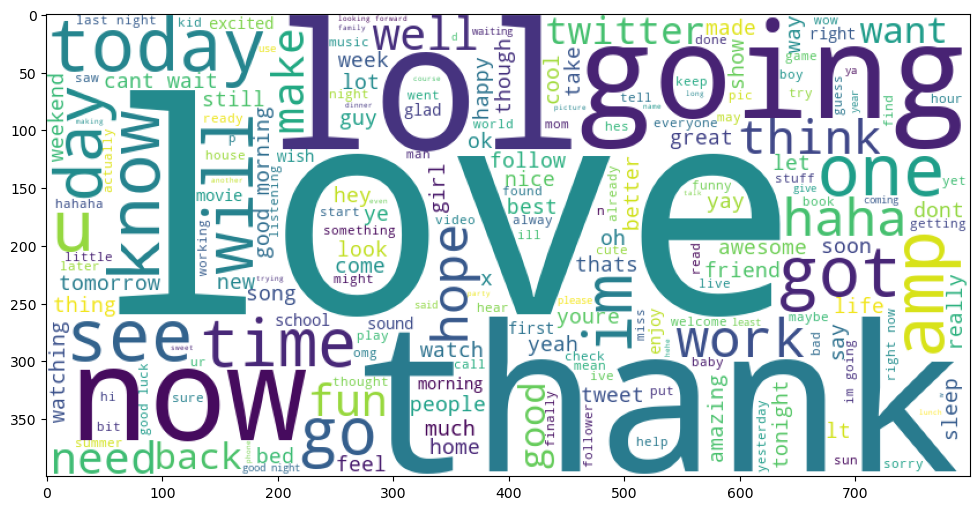

In [98]:
import matplotlib.pyplot as plt
plt.figure(figsize = (15,6))
plt.imshow(positive_wc)

In [99]:
negative_wc = wc.generate(df[df['target'] == 0]['clean_text'].str.cat(sep=" "))

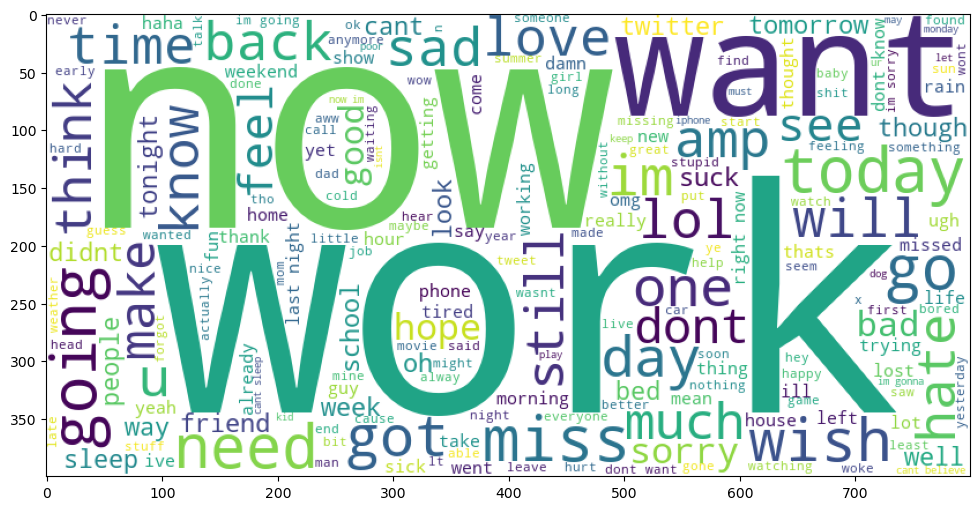

In [100]:
plt.show(negative_wc)

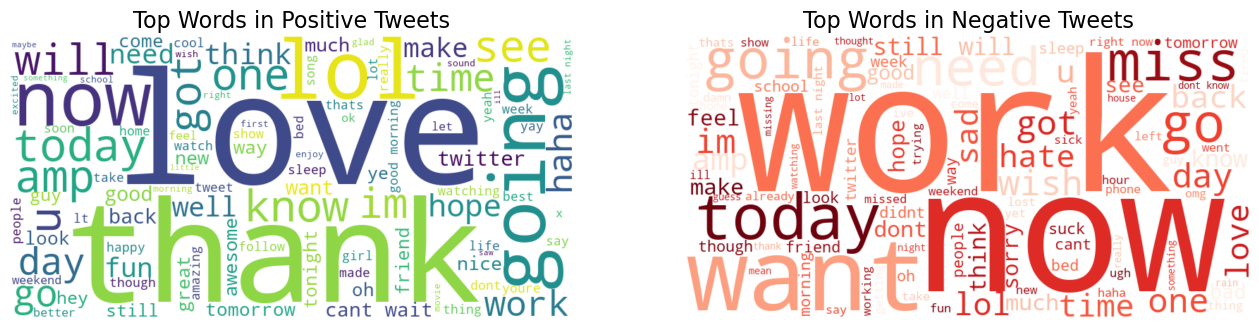

In [107]:
# Separate your final data by sentiment
positive_tweets = " ".join(df[df['target'] == 4]['clean_text'])
negative_tweets = " ".join(df[df['target'] == 0]['clean_text'])

# Create a subplot grid
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Generate Positive WordCloud
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(positive_tweets)
ax[0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0].set_title('Top Words in Positive Tweets', fontsize=16)
ax[0].axis('off')

# Generate Negative WordCloud
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Reds').generate(negative_tweets)
ax[1].imshow(wordcloud_neg, interpolation='bilinear')
ax[1].set_title('Top Words in Negative Tweets', fontsize=16)
ax[1].axis('off')

plt.show()

## 3. Model Training

In [109]:
# Logestic Regression Approach
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

lr = LogisticRegression()

In [111]:
lr.fit(X_tfidf_train, y_train)
y_lr_pred = lr.predict(X_tfidf_test)

C:\Users\RISHI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [113]:
print(accuracy_score(y_test, y_lr_pred))
print(confusion_matrix(y_test, y_lr_pred))
#print(precision_score(y_test, y_lr_pred))

0.8190844828076114
[[129802  28769]
 [ 28534 129634]]


In [114]:
# Navie Bayes Approach
from sklearn.naive_bayes import MultinomialNB
Mnb = MultinomialNB()

In [115]:
Mnb.fit(X_tfidf_train, y_train)
y_Mnb_pred = Mnb.predict(X_tfidf_test)

In [116]:
print(accuracy_score(y_test, y_Mnb_pred))
print(confusion_matrix(y_test, y_Mnb_pred))

0.8023041052727956
[[133411  25160]
 [ 37458 120710]]


In [117]:
# SVC
from sklearn.svm import LinearSVC
Linear_svm = LinearSVC()

In [118]:
Linear_svm.fit(X_tfidf_train, y_train)
y_lsvm_pred = Linear_svm.predict(X_tfidf_test)

In [119]:
print(accuracy_score(y_test, y_lsvm_pred))
print(confusion_matrix(y_test, y_lsvm_pred))

0.8157284073006482
[[129494  29077]
 [ 29289 128879]]
